# Custom Mesh Generator

We aim to create a mesh for the given area:
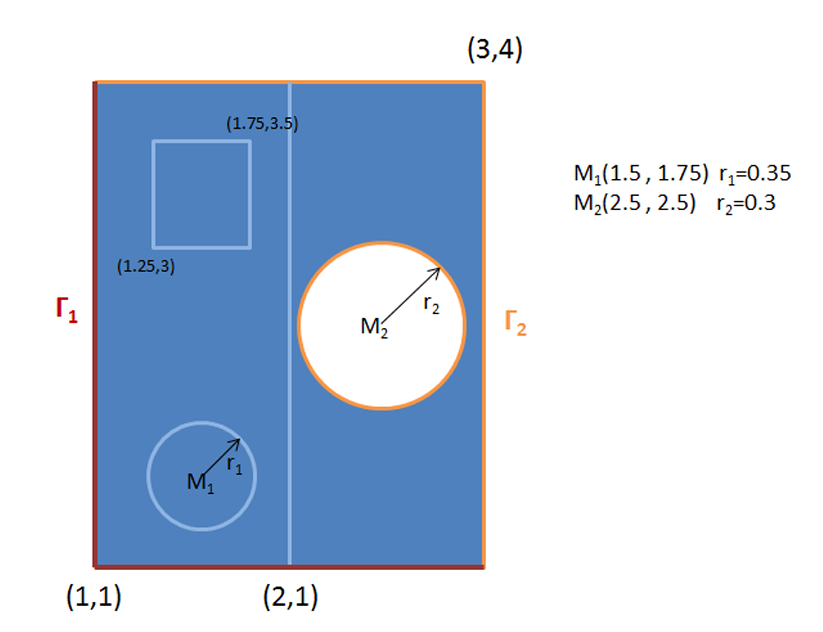

In [1]:
import pefile

pe = pefile.PE("_internals.cp313-win_amd64.pyd")

if hasattr(pe, "DIRECTORY_ENTRY_IMPORT"):
    for entry in pe.DIRECTORY_ENTRY_IMPORT:
        dll_name = entry.dll.decode() if entry.dll else "<unknown>"
        print(f"Imported DLL: {dll_name}")
        for imp in entry.imports:
            name = imp.name.decode() if imp.name else f"<ordinal {imp.ordinal}>"
            print(f"  {name}")
else:
    print("No import directory found.")


Imported DLL: libgcc_s_seh-1.dll
  _Unwind_Resume
Imported DLL: KERNEL32.dll
  DeleteCriticalSection
  EnterCriticalSection
  GetLastError
  InitializeCriticalSection
  LeaveCriticalSection
  Sleep
  TlsGetValue
  VirtualProtect
  VirtualQuery
Imported DLL: api-ms-win-crt-convert-l1-1-0.dll
  strtol
Imported DLL: api-ms-win-crt-environment-l1-1-0.dll
  __p__environ
  __p__wenviron
Imported DLL: api-ms-win-crt-heap-l1-1-0.dll
  _set_new_mode
  calloc
  free
  malloc
Imported DLL: api-ms-win-crt-locale-l1-1-0.dll
  localeconv
Imported DLL: api-ms-win-crt-math-l1-1-0.dll
  __setusermatherr
  acos
Imported DLL: api-ms-win-crt-private-l1-1-0.dll
  memcpy
  memmove
  strchr
  strstr
Imported DLL: api-ms-win-crt-runtime-l1-1-0.dll
  __p___argc
  __p___argv
  __p___wargv
  _configure_narrow_argv
  _configure_wide_argv
  _crt_at_quick_exit
  _crt_atexit
  _errno
  _execute_onexit_table
  _initialize_narrow_environment
  _initialize_onexit_table
  _initialize_wide_environment
  _initterm
  _regi

In [2]:
import pefile
pe = pefile.PE("_internals.cp313-win_amd64.pyd")
print([entry.name for entry in pe.DIRECTORY_ENTRY_IMPORT])

AttributeError: 'ImportDescData' object has no attribute 'name'

In [ ]:
import ctypes.util

print("libstdc++:", ctypes.util.find_library("libstdc++-6"))
print("libgcc:", ctypes.util.find_library("libgcc_s_seh-1"))


libstdc++: C:\Strawberry\c\bin\libstdc++-6.dll
libgcc: C:\Strawberry\c\bin\libgcc_s_seh-1.dll


In [6]:
import pefile
import os
import ctypes
from pathlib import Path

dll_search_paths = os.environ["PATH"].split(";")
checked = set()
missing = set()

def find_dll(dll_name):
    for path in dll_search_paths:
        dll_path = Path(path) / dll_name
        if dll_path.exists():
            return str(dll_path)
    return None

def process_dll(path):
    if not os.path.exists(path) or path in checked:
        return
    checked.add(path)

    try:
        pe = pefile.PE(path)
    except Exception as e:
        print(f"❌ Could not load {path}: {e}")
        return

    if not hasattr(pe, "DIRECTORY_ENTRY_IMPORT"):
        return

    for entry in pe.DIRECTORY_ENTRY_IMPORT:
        dll = entry.dll.decode(errors='ignore')
        if dll.lower() in checked:
            continue

        dll_path = find_dll(dll)
        if dll_path:
            process_dll(dll_path)
        else:
            missing.add(dll)

# Start with your .pyd
start = "_internals.cp313-win_amd64.pyd"
process_dll(start)

print("\n✅ DLLs checked:", len(checked))
if missing:
    print("❌ Missing DLLs:")
    for dll in sorted(missing):
        print("  ", dll)
else:
    print("🎉 All dependent DLLs found!")



✅ DLLs checked: 56
❌ Missing DLLs:
   api-ms-win-core-apiquery-l1-1-0.dll
   api-ms-win-core-appcompat-l1-1-0.dll
   api-ms-win-core-appcompat-l1-1-1.dll
   api-ms-win-core-comm-l1-1-0.dll
   api-ms-win-core-console-l1-2-1.dll
   api-ms-win-core-console-l1-2-2.dll
   api-ms-win-core-console-l2-1-0.dll
   api-ms-win-core-console-l2-2-0.dll
   api-ms-win-core-console-l3-2-0.dll
   api-ms-win-core-crt-l1-1-0.dll
   api-ms-win-core-crt-l2-1-0.dll
   api-ms-win-core-datetime-l1-1-1.dll
   api-ms-win-core-datetime-l1-1-2.dll
   api-ms-win-core-debug-l1-1-1.dll
   api-ms-win-core-delayload-l1-1-0.dll
   api-ms-win-core-delayload-l1-1-1.dll
   api-ms-win-core-errorhandling-l1-1-2.dll
   api-ms-win-core-errorhandling-l1-1-3.dll
   api-ms-win-core-fibers-l2-1-0.dll
   api-ms-win-core-fibers-l2-1-1.dll
   api-ms-win-core-file-l1-2-1.dll
   api-ms-win-core-file-l1-2-2.dll
   api-ms-win-core-file-l1-2-4.dll
   api-ms-win-core-file-l1-2-5.dll
   api-ms-win-core-file-l2-1-1.dll
   api-ms-win-core-fi

In [8]:
from pathlib import Path
import os

dll_dirs = os.environ["PATH"].split(";")
dlls = ["libwinpthread-1.dll"]

for dll in dlls:
    found = any((Path(p) / dll).exists() for p in dll_dirs if Path(p).is_dir())
    print(f"{dll}: {'✅ Found' if found else '❌ Not found'}")


libwinpthread-1.dll: ✅ Found


In [7]:
import ctypes
ctypes.CDLL("./_internals.cp313-win_amd64.pyd")

FileNotFoundError: Could not find module 'c:\Users\Jax\Coding\Finite-Element-Solver\Übungsaufgaben\Übung 2D\_internals.cp313-win_amd64.pyd' (or one of its dependencies). Try using the full path with constructor syntax.

In [2]:
import pefile
import ctypes
import os
import sys

def find_dll(dll_name):
    """Try to find DLL in system PATH or current directory."""
    # Check if dll_name is an absolute or relative path and exists
    if os.path.isabs(dll_name) and os.path.exists(dll_name):
        return dll_name
    if os.path.exists(dll_name):
        return dll_name

    # Search in current directory
    cur_dir = os.path.abspath(os.path.dirname(__file__))
    candidate = os.path.join(cur_dir, dll_name)
    if os.path.exists(candidate):
        return candidate

    # Search in PATH environment variable
    paths = os.environ.get('PATH', '').split(os.pathsep)
    for path in paths:
        candidate = os.path.join(path, dll_name)
        if os.path.exists(candidate):
            return candidate

    # Not found
    return None

def check_dll_load(dll_path):
    try:
        ctypes.CDLL(dll_path)
        return True
    except Exception as e:
        return False

def main(pyd_path):
    print(f"Checking dependencies for: {pyd_path}")
    pe = pefile.PE(pyd_path)
    dependencies = []
    for entry in pe.DIRECTORY_ENTRY_IMPORT:
        dependencies.append(entry.dll.decode('utf-8'))

    print(f"Found dependencies ({len(dependencies)}):")
    for dll in dependencies:
        print(f" - {dll}")

    print("\nLoading each dependency:")
    for dll in dependencies:
        path = find_dll(dll)
        if path is None:
            print(f"❌ {dll}: NOT FOUND")
        else:
            success = check_dll_load(path)
            if success:
                print(f"✅ {dll}: Loaded successfully from {path}")
            else:
                print(f"❌ {dll}: Found at {path} but failed to load")

if __name__ == "__main__":
    if len(sys.argv) < 2:
        print("Usage: python check_dlls.py path_to_pyd_file")
        sys.exit(1)

    pyd_file = sys.argv[1]
    if not os.path.isfile(pyd_file):
        print(f"File not found: {pyd_file}")
        sys.exit(1)

    # In Jupyter cell, replace with your actual path:
    main(r"c:\Users\Jax\Coding\Finite-Element-Solver\Übungsaufgaben\Übung 2D\_internals.cp313-win_amd64.pyd")



File not found: --f=c:\Users\Jax\AppData\Roaming\jupyter\runtime\kernel-v3aec6d3f10d48053790fc493abf7ee1d02ce0d5ab.json


SystemExit: 1

In [4]:
import os
print(os.environ.get("PATH", ""))


c:\Users\Jax\Coding\Finite-Element-Solver\.venv\Scripts;C:\Users\Jax\Coding\Finite-Element-Solver\.venv\Scripts;C:\Program Files (x86)\oh-my-posh\bin\;C:\WINDOWS\system32;C:\WINDOWS;C:\WINDOWS\System32\Wbem;C:\WINDOWS\System32\WindowsPowerShell\v1.0\;C:\WINDOWS\System32\OpenSSH\;C:\Program Files\NVIDIA Corporation\NVIDIA app\NvDLISR;C:\Program Files (x86)\NVIDIA Corporation\PhysX\Common;C:\Program Files\MATLAB\R2024b\bin;C:\Program Files\gsudo\Current;C:\Strawberry\c\bin;C:\Strawberry\perl\site\bin;C:\Strawberry\perl\bin;C:\Program Files\dotnet\;C:\Program Files\Git\cmd;C:\Users\Jax\AppData\Local\Programs\Python\Python313\Scripts\;C:\Users\Jax\AppData\Local\Programs\Python\Python313\;C:\Users\Jax\scoop\shims;C:\Users\Jax\AppData\Local\Microsoft\WindowsApps;C:\Users\Jax\AppData\Local\Microsoft\WinGet\Links;C:\Users\Jax\AppData\Local\Programs\Microsoft VS Code\bin;C:\Users\Jax\AppData\Local\Programs\MiKTeX\miktex\bin\x64\;C:\msys64\ucrt64\bin;C:\Strawberry\c\bin;


In [3]:
import sys
print(sys.version)
print(sys.executable)


3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
c:\Users\Jax\Coding\Finite-Element-Solver\.venv\Scripts\python.exe


In [2]:
import numpy as np
# import meshtools as mt



import _internals
print(dir(_internals))

ImportError: DLL load failed while importing _internals: The specified module could not be found.

In [ ]:
LENGTH = 0.1
LOWER_LEFT = [1,1]
UPPER_RIGHT = [3,4]


In [ ]:
knots, elements = mt.RectangleSegments(LOWER_LEFT, UPPER_RIGHT, edge_length=LENGTH)